# Tsuboyama 2023 mega-scale stability — schema & data prep

Prepares the reward targets and DPO preference pairs for the **RL-ESM** project from the
[Tsuboyama et al. 2023](https://www.nature.com/articles/s41586-023-06328-6) mega-scale
folding-stability dataset (Zenodo record `7992926`).

**Source of truth:** `data/tsuboyama/Tsuboyama2023_Dataset2_Dataset3_20230416.csv`
(776k rows). This is the ML-processed table with amino-acid sequences and folding ΔG —
the one ProteinDPO / ESM use. `Dataset1` is DNA-only with no `aa_seq`, so we skip it.

> Run `python download_tsuboyama.py --match Processed_K50_dG_datasets` and unzip first.

## Schema (columns we use)

| column | meaning |
|---|---|
| `name` | unique id: `WT.pdb` or `WT.pdb_<MUT>` (e.g. `1A32.pdb_A45D`) |
| `aa_seq` | the assayed protein sequence (what ESM-C embeds) |
| `mut_type` | `wt`, a substitution (`A45D`), or an indel (`insG2`, `del…`) |
| `WT_name` | parent wild-type domain (groups mutants) |
| `WT_cluster` | fold/topology label (numeric = natural cluster, e.g. `EEHH`/`HHH` = de novo) |
| `dG_ML` | **folding free energy ΔG** (kcal/mol). *Censored:* `<-1`, `>5`, `-` |
| `ddG_ML` | ΔΔG of the mutation vs its WT (same censoring) |
| `Stabilizing_mut` | `True`/`False`/`-` |

**Censoring matters:** `<-1` = too unstable to measure, `>5` = too stable. Naive
`float()` drops ~100k rows. We map the bounds to their limits instead.

## Load

In [1]:
import warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA = Path("../data/tsuboyama")
CSV = DATA / "Tsuboyama2023_Dataset2_Dataset3_20230416.csv"
assert CSV.exists(), f"missing {CSV} -- download + unzip Processed_K50_dG_datasets.zip"
print("csv:", CSV.name, f"({CSV.stat().st_size/1e6:.0f} MB)")

csv: Tsuboyama2023_Dataset2_Dataset3_20230416.csv (698 MB)


In [2]:
USECOLS = ["name","aa_seq","mut_type","WT_name","WT_cluster",
           "dG_ML","ddG_ML","Stabilizing_mut"]

def parse_dG(x):
    """Parse censored ML folding stabilities to floats."""
    if x == "<-1": return -1.0   # unmeasurably unstable -> lower bound
    if x == ">5":  return 5.0    # unmeasurably stable   -> upper bound
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan            # "-" and blanks -> missing

# low_memory=False: single-pass read. The default chunked reader hits a pandas
# IndexError on the mixed-dtype columns WT_cluster (ints+codes) and dG_ML (floats+"<-1").
df = pd.read_csv(CSV, usecols=USECOLS, low_memory=False)
df["dG"]  = df["dG_ML"].map(parse_dG)
df["ddG"] = df["ddG_ML"].map(parse_dG)
df["WT_cluster"] = df["WT_cluster"].astype(str)
df["is_wt"] = df["mut_type"].eq("wt")

print("rows:", len(df), "| mem MB:", round(df.memory_usage(deep=True).sum()/1e6, 1))
print("dG missing:", int(df.dG.isna().sum()),
      "| censored <-1:", int((df.dG_ML == "<-1").sum()),
      "| censored >5:", int((df.dG_ML == ">5").sum()))
df.head(3)

rows: 776298 | mem MB: 419.1
dG missing: 4537 | censored <-1: 53235 | censored >5: 43059


,name,aa_seq,mut_type,WT_name,WT_cluster,dG_ML,ddG_ML,Stabilizing_mut,dG,ddG,is_wt
0,EA|run2_0325_0005.pdb,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,3.3321258839433834,0.01719762915616707,False,3.332126,0.017198,True
1,EA|run2_0325_0005.pdb_wtm,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,3.3998316632160224,0.08490340842880606,False,3.399832,0.084903,True
2,EA|run2_0325_0005.pdb_wte,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,3.315782210420261,0.0008539556330444675,False,3.315782,0.000854,True


## Exploratory stats

In [3]:
def mut_class(m):
    m = str(m)
    if m == "wt": return "wt"
    if m.startswith("ins"): return "insertion"
    if m.startswith("del"): return "deletion"
    return "substitution"

print("WT proteins:", df.WT_name.nunique())
print("\nmutation types:")
print(df.mut_type.map(mut_class).value_counts())
print("\nStabilizing_mut:", df.Stabilizing_mut.value_counts().to_dict())

# natural vs de novo: de novo domains carry a topology-code cluster
# (EEHH, HHH, EHEE, HEEH, EEHEE, hall); natural domains a numeric cluster id.
df["origin"] = np.where(df.WT_cluster.str.fullmatch(r"\d+"), "natural", "de_novo")
by_origin = df.drop_duplicates("WT_name").origin.value_counts().to_dict()
print(f"\nWT domains -> natural={by_origin.get('natural')}  de_novo={by_origin.get('de_novo')}  (paper: 331 + 148)")
print("de novo topologies:", sorted(df.loc[df.origin=='de_novo','WT_cluster'].unique()))
print("rows by origin:", df.origin.value_counts().to_dict())

WT proteins: 479

mutation types:
mut_type
substitution    698032
insertion        50643
deletion         25275
wt                2348
Name: count, dtype: int64

Stabilizing_mut: {'False': 579808, '-': 193556, 'True': 2934}

WT domains -> natural=331  de_novo=148  (paper: 331 + 148)
de novo topologies: ['EEHEE', 'EEHH', 'EHEE', 'HEEH', 'HHH', 'hall']
rows by origin: {'natural': 626120, 'de_novo': 150178}


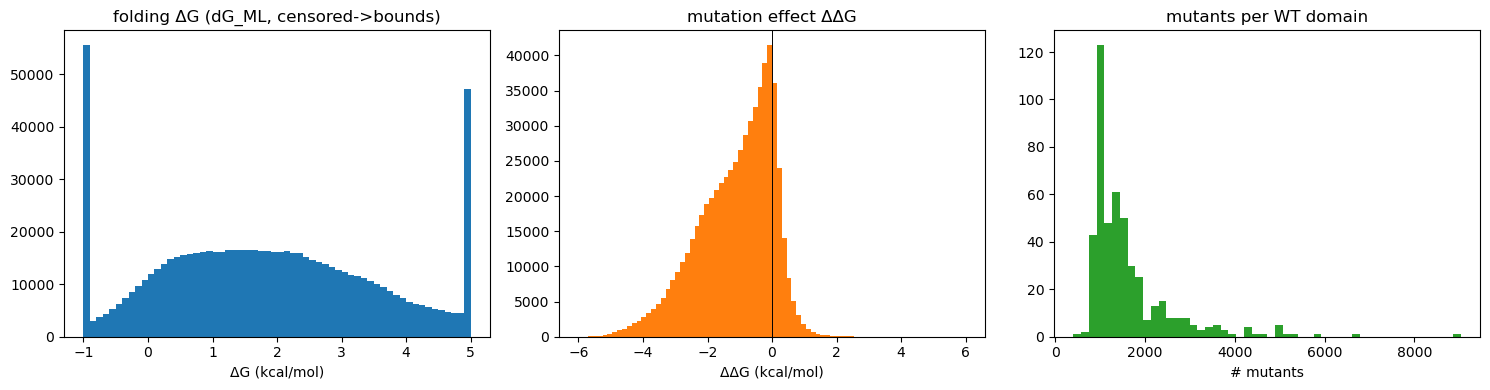

aa_seq length: min 31  median 58  max 75


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df.dG.dropna(), bins=60, color="C0")
ax[0].set_title("folding ΔG (dG_ML, censored->bounds)"); ax[0].set_xlabel("ΔG (kcal/mol)")

ddg = df.loc[~df.is_wt, "ddG"].dropna()
ax[1].hist(ddg, bins=80, range=(-6, 6), color="C1")
ax[1].axvline(0, color="k", lw=.7)
ax[1].set_title("mutation effect ΔΔG"); ax[1].set_xlabel("ΔΔG (kcal/mol)")

per_wt = df[~df.is_wt].groupby("WT_name").size()
ax[2].hist(per_wt, bins=50, color="C2")
ax[2].set_title("mutants per WT domain"); ax[2].set_xlabel("# mutants")
plt.tight_layout(); plt.show()
print("aa_seq length: min %d  median %d  max %d" % (
    df.aa_seq.str.len().min(), int(df.aa_seq.str.len().median()), df.aa_seq.str.len().max()))

## Map to the RL project

- **Reward target** — `aa_seq -> dG` (folding stability). Fit the ridge probe / regression
  reward on this. `ddG` is the mutation-effect label if you prefer a relative reward.
- **DPO preference pairs** — within each WT domain, a higher-ΔG variant is *preferred* over
  a lower-ΔG one (margin filter for confident pairs).
- **Held-out split** — reserve the **de novo** domains for evaluation (leakage-free: not in
  ESM/ESMFold pretraining). Build reward + pairs from **natural** domains only.

In [5]:
OUT = Path("../data/prepared"); OUT.mkdir(parents=True, exist_ok=True)

# reward table: keep rows with a measured dG; carry origin so we can honour the split
reward = (df[df.dG.notna()]
          .loc[:, ["name","WT_name","origin","WT_cluster","mut_type","is_wt","aa_seq","dG","ddG"]]
          .reset_index(drop=True))
reward.to_csv(OUT/"reward_table.csv", index=False)
print("reward rows:", len(reward), "->", OUT/"reward_table.csv")
reward.head(3)

reward rows: 771761 -> data/prepared/reward_table.csv


,name,WT_name,origin,WT_cluster,mut_type,is_wt,aa_seq,dG,ddG
0,EA|run2_0325_0005.pdb,EA|run2_0325_0005.pdb,de_novo,EEHH,wt,True,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,3.332126,0.017198
1,EA|run2_0325_0005.pdb_wtm,EA|run2_0325_0005.pdb,de_novo,EEHH,wt,True,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,3.399832,0.084903
2,EA|run2_0325_0005.pdb_wte,EA|run2_0325_0005.pdb,de_novo,EEHH,wt,True,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,3.315782,0.000854


In [6]:
# DPO preference pairs -- NATURAL domains only (de novo is held out for eval)
rng = np.random.default_rng(0)
MARGIN = 1.0            # kcal/mol: min ΔG gap for a confident preference
MAX_PAIRS_PER_WT = 200

train = reward[reward.origin == "natural"]
pairs = []
for wt, g in train.groupby("WT_name"):
    seqs, dGs = g.aa_seq.to_numpy(), g.dG.to_numpy()
    n = len(g)
    if n < 2: continue
    cand = rng.integers(0, n, size=(min(MAX_PAIRS_PER_WT * 6, n * n), 2))
    cand = cand[cand[:, 0] != cand[:, 1]]
    kept = 0
    for i, j in cand:
        if abs(dGs[i] - dGs[j]) < MARGIN: continue
        hi, lo = (i, j) if dGs[i] > dGs[j] else (j, i)
        pairs.append((wt, seqs[hi], seqs[lo], float(dGs[hi]), float(dGs[lo])))
        kept += 1
        if kept >= MAX_PAIRS_PER_WT: break

dpo = pd.DataFrame(pairs, columns=["WT_name","chosen","rejected","dG_chosen","dG_rejected"])
dpo.to_csv(OUT/"dpo_pairs.csv", index=False)
print(f"DPO pairs: {len(dpo)} across {dpo.WT_name.nunique()} natural domains -> {OUT/'dpo_pairs.csv'}")
dpo.head(3)

DPO pairs: 66012 across 331 natural domains -> data/prepared/dpo_pairs.csv


,WT_name,chosen,rejected,dG_chosen,dG_rejected
0,1A0N.pdb,VTLFVALYDYEARTEDDLSFHKGCKFQILNSSEGDWWEARLLTTGE...,VTLFVALYDYEARTEDDLSFHKGWKFQILNSSEGDWWEARPLTTGE...,3.680976,0.840615
1,1A0N.pdb,VTLFVALYDYEARTEDDLSFHKGQKFQILNSSEGDWWEARWLTTGE...,VTLFVALYDYEARTEDDLSFHKGKKFQILNSSEGDWWEARQLTTGE...,2.296087,0.620317
2,1A0N.pdb,VTLFVALYDYEARTEDDLSFHKGHKFQILNSSEGDWWEARSLTTGE...,VTLFVALYDYEARTEDDLSFHKGWKFQILNSSEGDWWEARDLTTGE...,4.172556,2.451153


In [16]:
# per-WT split assignment (train = natural, held-out = de novo)
split = (df.drop_duplicates("WT_name")[["WT_name","origin","WT_cluster"]]
         .assign(split=lambda d: np.where(d.origin == "de_novo",
                                           "heldout_denovo", "train_natural"))
         .reset_index(drop=True))
split.to_csv(OUT/"wt_split.csv", index=False)
print(split.split.value_counts().to_dict())
split.head()

{'train_natural': 331, 'heldout_denovo': 148}


,WT_name,origin,WT_cluster,split
0,EA|run2_0325_0005.pdb,de_novo,EEHH,heldout_denovo
1,EA|run3_0321_0005.pdb,de_novo,EEHH,heldout_denovo
2,EA|run3_0525_0006.pdb,de_novo,EEHH,heldout_denovo
3,EA|run3_1140_0005.pdb,de_novo,EEHH,heldout_denovo
4,EA|run5_0050_0004.pdb,de_novo,EEHH,heldout_denovo


## Next steps

1. `reward/fit_probe.py` — ridge probe on frozen ESM-C penultimate embeddings of `aa_seq`
   -> `dG`, report held-out Spearman on de novo domains (**gate before any alignment**).
2. `align/train_dpo.py` — DPO on `dpo_pairs.csv`.
3. `align/train_grpo.py` — GRPO with the probe as reward.
4. Validate both on the held-out de novo domains + ProteinGym; log the reward-hacking gap.
